**Configuration note:** this notebook analyzes paralog RNA-seq expression. It reads `paralog_families_counts.tsv` (featureCounts / Salmon TPM) and `paralog_families.tsv` (family metadata from `build_paralog_families.py`) from the working directory. Inputs mirror `config.sh` at the repo root.


# Paralog Expression Heatmap Across Tissues

**ComplexHeatmap (R/Bioconductor) implementation**

- Rows: 2,181 paralogs, clustered within family blocks
- Columns: 29 RNA-seq samples, grouped by tissue
- Right annotation: top-40 family labels with connecting lines (`anno_mark`)
- Top annotation: tissue color bar + tissue names

Run with the `r-visualizations` conda environment (R kernel).

In [8]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
})
ht_opt$message <- FALSE

In [9]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
counts_raw <- read.table('/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/paralog-alignment-visualization/paralog_families_counts.tsv', sep = '\t',
                         header = TRUE, comment.char = '#',
                         row.names = 1, check.names = FALSE)

# Extract count columns (SRR*)
sample_cols_orig <- grep('^SRR', colnames(counts_raw), value = TRUE)
counts <- counts_raw[, sample_cols_orig, drop = FALSE]
colnames(counts) <- gsub('_Aligned.sortedByCoord.out.bam', '', colnames(counts))
sample_list <- colnames(counts)

# Load family metadata
families_df <- read.table('/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/paralog-alignment-visualization/paralog_families.tsv', sep = '\t', header = TRUE,
                          stringsAsFactors = FALSE)
rownames(families_df) <- families_df$gene_id

cat(sprintf('Genes in counts: %d\n', nrow(counts)))
cat(sprintf('Genes in families: %d\n', nrow(families_df)))

Genes in counts: 3272
Genes in families: 3272


In [10]:
# ---------------------------------------------------------------------------
# Merge and filter to paralogs only, then TPM-normalize
# ---------------------------------------------------------------------------
meta_cols <- c('family', 'gene_name', 'gene_type', 'paralog_type', 'length')
merged <- merge(counts, families_df[, meta_cols, drop = FALSE], by = 'row.names')
rownames(merged) <- merged$Row.names
merged$Row.names <- NULL

paralogs <- merged[merged$gene_type != 'parent', ]
cat(sprintf('Paralogs (non-parent): %d\n', nrow(paralogs)))

# TPM normalization
gene_lengths <- paralogs$length
rpk <- paralogs[, sample_list] / (gene_lengths / 1000)
rpk <- as.matrix(rpk)
tpm <- sweep(rpk, 2, colSums(rpk), '/') * 1e6

cat(sprintf('TPM matrix: %d genes x %d samples\n', nrow(tpm), ncol(tpm)))

Paralogs (non-parent): 2181
TPM matrix: 2181 genes x 29 samples


In [11]:
# ---------------------------------------------------------------------------
# Sample / tissue metadata
# ---------------------------------------------------------------------------
sample_tissue <- c(
  'SRR17216293' = 'skin',    'SRR17216294' = 'brain',   'SRR17216295' = 'heart',
  'SRR17216296' = 'kidney',  'SRR17216297' = 'liver',   'SRR17216298' = 'lung',
  'SRR17216299' = 'skin',    'SRR17216300' = 'brain',   'SRR17216301' = 'heart',
  'SRR17216302' = 'kidney',  'SRR17216303' = 'liver',   'SRR17216304' = 'lung',
  'SRR17216305' = 'skin',    'SRR17216306' = 'brain',   'SRR17216307' = 'heart',
  'SRR17216308' = 'kidney',  'SRR17216309' = 'liver',   'SRR17216310' = 'lung',
  'SRR17216311' = 'brain',   'SRR17216312' = 'heart',   'SRR17216313' = 'kidney',
  'SRR17216314' = 'kidney',  'SRR17216315' = 'lung',    'SRR17216316' = 'skin',
  'SRR17216317' = 'heart',   'SRR17216318' = 'kidney',  'SRR17216319' = 'liver',
  'SRR17216320' = 'brain',   'SRR17216321' = 'lung'
)
tissues <- c('skin', 'brain', 'heart', 'kidney', 'liver', 'lung')
tissue_colors <- c(
  'skin'   = '#E8A87C',
  'brain'  = '#C38D9E',
  'heart'  = '#E27D60',
  'kidney' = '#85CDCA',
  'liver'  = '#D4A574',
  'lung'   = '#41B3A3'
)

# Sort samples by tissue
tissue_order_idx <- match(sample_tissue[sample_list], tissues)
sample_order_idx <- order(tissue_order_idx)
sample_order <- sample_list[sample_order_idx]
tpm_sorted <- tpm[, sample_order]

cat('Sample order:', sample_order, '\n')

Sample order: SRR17216293 SRR17216299 SRR17216305 SRR17216316 SRR17216294 SRR17216300 SRR17216306 SRR17216311 SRR17216320 SRR17216295 SRR17216301 SRR17216307 SRR17216312 SRR17216317 SRR17216296 SRR17216302 SRR17216308 SRR17216313 SRR17216314 SRR17216318 SRR17216297 SRR17216303 SRR17216309 SRR17216319 SRR17216298 SRR17216304 SRR17216310 SRR17216315 SRR17216321 


In [12]:
# ---------------------------------------------------------------------------
# Row ordering: cluster families (ward linkage), then sort paralogs within
# each family by mean expression (descending)
# ---------------------------------------------------------------------------

# Compute per-family mean expression
family_mean <- aggregate(tpm, by = list(family = paralogs$family), FUN = mean)
rownames(family_mean) <- family_mean$family
family_mean$family <- NULL
family_mean <- as.matrix(family_mean)

# Cluster families (ward.D2 matches Python scipy linkage(method='ward'))
family_dist <- dist(family_mean)
family_hclust <- hclust(family_dist, method = 'ward.D2')
family_order <- family_hclust$labels[family_hclust$order]

# Within each family, sort paralogs by total expression (descending)
row_order <- c()
family_boundaries <- list()

for (fam in family_order) {
  fam_mask <- paralogs$family == fam
  fam_genes <- rownames(paralogs)[fam_mask]
  fam_expr <- rowMeans(tpm_sorted[fam_genes, , drop = FALSE])
  fam_order_genes <- names(sort(fam_expr, decreasing = TRUE))

  start <- length(row_order) + 1
  row_order <- c(row_order, fam_order_genes)
  end <- length(row_order)
  family_boundaries[[fam]] <- c(start = start, end = end)
}

tpm_ordered <- tpm_sorted[row_order, ]

# Log-transform for visualization
log_tpm <- log2(as.matrix(tpm_ordered) + 0.1)

cat(sprintf('Heatmap dimensions: %d rows x %d columns\n',
            nrow(log_tpm), ncol(log_tpm)))
cat(sprintf('Families: %d\n', length(family_order)))

Heatmap dimensions: 2181 rows x 29 columns
Families: 1091


In [13]:
# ---------------------------------------------------------------------------
# Top-40 largest families for right-side annotation
# ---------------------------------------------------------------------------
family_sizes <- table(paralogs$family)
top40_fams <- names(sort(family_sizes, decreasing = TRUE)[1:min(40, length(family_sizes))])

# Build anno_mark data: midpoints + labels for each top-40 family
mark_at <- c()
mark_labels <- c()

for (fam in family_order) {
  if (fam %in% top40_fams) {
    bounds <- family_boundaries[[fam]]
    mid <- (bounds['start'] + bounds['end']) / 2
    n_members <- bounds['end'] - bounds['start'] + 1
    mark_at <- c(mark_at, mid)
    mark_labels <- c(mark_labels, sprintf('%s  (%d)', fam, n_members))
  }
}

cat(sprintf('Annotated families: %d\n', length(mark_at)))

Annotated families: 40


In [14]:
# ---------------------------------------------------------------------------
# Column annotation (tissue color bar) + color mapping
# ---------------------------------------------------------------------------
col_tissue <- sample_tissue[sample_order]
col_tissue_factor <- factor(col_tissue, levels = tissues)

# Top annotation: colored bar for each tissue
col_anno <- HeatmapAnnotation(
  Tissue = col_tissue_factor,
  col = list(Tissue = tissue_colors),
  show_legend = FALSE,
  annotation_name_side = 'left',
  annotation_name_gp = gpar(fontsize = 0),
  simple_anno_size = unit(0.35, 'cm'),
  border = FALSE,
  gap = unit(0, 'mm')
)

# Color mapping (YlOrRd-like, matches Python matplotlib YlOrRd colormap)
vmax <- quantile(log_tpm, 0.99)
col_fun <- colorRamp2(
  seq(-3, vmax, length.out = 9),
  c('#FFFFCC', '#FFEDA0', '#FED976', '#FEB24C', '#FD8D3C',
    '#FC4E2A', '#E31A1C', '#BD0026', '#800026')
)

cat(sprintf('Color scale: -3 to %.2f (99th percentile)\n', vmax))

Color scale: -3 to 12.77 (99th percentile)


In [15]:
# ============================================================================
# Compact ComplexHeatmap with adjustable heatmap size and font scaling
#
# Required objects already defined:
#   log_tpm, sample_tissue, tissues, tissue_colors
#   paralogs, col_fun
# ============================================================================

library(ComplexHeatmap)
library(circlize)
library(grid)

# ============================================================================
# USER-ADJUSTABLE FIGURE SETTINGS
# ============================================================================

# Number of largest paralog families to annotate.
# If multiple families tie with the 40th-ranked family, all tied families
# are included, so the final number of annotations may exceed 40.
TOP_N_FAMILIES <- 40

# Heatmap BODY dimensions only.
HEATMAP_WIDTH_CM  <- 12
HEATMAP_HEIGHT_CM <- 30

# Master font multiplier.
# 1.0 = original font sizes
# 1.2 = 20% larger
# 1.4 = 40% larger
FONT_SCALE <- 1.2

# Jupyter preview canvas
PREVIEW_WIDTH_IN  <- 7.5
PREVIEW_HEIGHT_IN <- 13

# Final saved figure dimensions
OUTPUT_WIDTH_IN  <- PREVIEW_WIDTH_IN
OUTPUT_HEIGHT_IN <- PREVIEW_HEIGHT_IN

# Right-side family annotation settings
FAMILY_LINK_WIDTH_MM <- 9
FAMILY_PADDING_MM    <- 1.2

# Raster quality
RASTER_QUALITY <- 3

# ============================================================================
# DERIVED FONT AND ANNOTATION SIZES
# ============================================================================

TITLE_FONT         <- 12.0 * FONT_SCALE
TISSUE_FONT        <- 12.0 * FONT_SCALE
REPLICATE_FONT     <- 9.5  * FONT_SCALE
AXIS_TITLE_FONT    <- 12.0 * FONT_SCALE
FAMILY_FONT        <- 7.5  * FONT_SCALE
LEGEND_TITLE_FONT  <- 10.5 * FONT_SCALE
LEGEND_LABEL_FONT  <- 9.0  * FONT_SCALE

TOP_LABEL_HEIGHT_MM <- 5.0 * FONT_SCALE
TOP_BAR_HEIGHT_MM   <- 2.5
BOTTOM_HEIGHT_MM    <- 4.5 * FONT_SCALE

# ============================================================================
# Confirm matrix and column annotation ordering
# ============================================================================

log_tpm <- as.matrix(log_tpm)

column_tissues <- sample_tissue[colnames(log_tpm)]

if (any(is.na(column_tissues))) {
  missing_samples <- colnames(log_tpm)[is.na(column_tissues)]

  stop(
    paste0(
      "Some log_tpm columns are missing tissue annotations: ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

# Keep only tissues represented in the matrix, preserving requested order
present_tissues <- tissues[tissues %in% column_tissues]

col_tissue_factor <- factor(
  column_tissues,
  levels = present_tissues
)

# Biological replicate counts by tissue
replicate_counts <- table(col_tissue_factor)

replicate_labels <- paste0(
  as.integer(replicate_counts[present_tissues]),
  " rep."
)

# Colors in tissue-split order
present_tissue_colors <- unname(
  tissue_colors[present_tissues]
)

if (any(is.na(present_tissue_colors))) {
  stop("At least one present tissue is missing from tissue_colors.")
}

# ============================================================================
# Select the top 40 largest paralog families, including ties
# ============================================================================

if (is.null(rownames(log_tpm))) {
  stop("log_tpm must have row names corresponding to paralog gene IDs.")
}

if (is.null(rownames(paralogs))) {
  stop("paralogs must have row names corresponding to paralog gene IDs.")
}

if (!all(rownames(log_tpm) %in% rownames(paralogs))) {
  missing_genes <- setdiff(
    rownames(log_tpm),
    rownames(paralogs)
  )

  stop(
    paste0(
      "Some log_tpm rows are missing from paralogs: ",
      paste(head(missing_genes, 10), collapse = ", ")
    )
  )
}

# Family assignments in the exact row order of the heatmap
family_by_row <- paralogs[
  rownames(log_tpm),
  "family"
]

if (any(is.na(family_by_row))) {
  stop("Some log_tpm rows have missing paralog-family assignments.")
}

# Count paralogs per family
family_sizes <- sort(
  table(family_by_row),
  decreasing = TRUE
)

TOTAL_FAMILY_COUNT <- length(family_sizes)

if (TOTAL_FAMILY_COUNT == 0) {
  stop("No paralog families were found.")
}

if (TOTAL_FAMILY_COUNT <= TOP_N_FAMILIES) {
  cutoff_family_size <- min(family_sizes)
  selected_families <- names(family_sizes)

} else {
  # Family size at rank 40
  cutoff_family_size <- unname(
    family_sizes[TOP_N_FAMILIES]
  )

  # Include all families tied with the family at rank 40
  selected_families <- names(
    family_sizes[
      family_sizes >= cutoff_family_size
    ]
  )
}

N_FAMILIES_ANNOTATED <- length(selected_families)

cat(
  "Requested top",
  TOP_N_FAMILIES,
  "paralog families.\n"
)

cat(
  "The",
  TOP_N_FAMILIES,
  "th-ranked family contains",
  cutoff_family_size,
  "paralogs.\n"
)

cat(
  "Annotating",
  N_FAMILIES_ANNOTATED,
  "families after including ties.\n"
)

# ============================================================================
# Determine anno_mark positions
#
# Each family is labeled at the midpoint of its row block.
# ============================================================================

family_row_positions <- lapply(
  selected_families,
  function(family_name) {
    which(family_by_row == family_name)
  }
)

names(family_row_positions) <- selected_families

mark_at <- vapply(
  family_row_positions,
  function(row_positions) {
    round(mean(range(row_positions)))
  },
  numeric(1)
)

# Add the number of paralogs in each family to the label
# Example: Family_123 (8)
mark_labels <- paste0(
  names(mark_at),
  " (",
  as.integer(family_sizes[names(mark_at)]),
  ")"
)

# Sort labels by heatmap row position
mark_order <- order(mark_at)

mark_at <- as.integer(mark_at[mark_order])
mark_labels <- mark_labels[mark_order]

# If two family midpoints happen to round to the same row, keep both by
# slightly separating duplicate positions where possible.
if (anyDuplicated(mark_at)) {
  duplicate_groups <- split(
    seq_along(mark_at),
    mark_at
  )

  for (idx in duplicate_groups) {
    if (length(idx) > 1) {
      offsets <- seq(
        from = -floor((length(idx) - 1) / 2),
        to = ceiling((length(idx) - 1) / 2)
      )

      mark_at[idx] <- mark_at[idx] + offsets
    }
  }

  mark_at <- pmax(
    1L,
    pmin(
      nrow(log_tpm),
      mark_at
    )
  )
}

cat(
  "Final anno_mark label count:",
  length(mark_labels),
  "\n"
)

# ============================================================================
# Top annotation
# ============================================================================

col_anno <- HeatmapAnnotation(
  Tissue_label = anno_block(
    labels = tools::toTitleCase(present_tissues),

    gp = gpar(
      fill = NA,
      col = NA
    ),

    labels_gp = gpar(
      fontsize = TISSUE_FONT,
      fontface = "bold",
      col = present_tissue_colors
    ),

    height = unit(
      TOP_LABEL_HEIGHT_MM,
      "mm"
    )
  ),

  Tissue_bar = anno_block(
    gp = gpar(
      fill = present_tissue_colors,
      col = NA
    ),

    height = unit(
      TOP_BAR_HEIGHT_MM,
      "mm"
    )
  ),

  show_annotation_name = FALSE,

  gap = unit(
    0.4,
    "mm"
  )
)

# ============================================================================
# Bottom annotation
# ============================================================================

bottom_anno <- HeatmapAnnotation(
  Replicate_count = anno_block(
    labels = replicate_labels,

    gp = gpar(
      fill = NA,
      col = NA
    ),

    labels_gp = gpar(
      fontsize = REPLICATE_FONT,
      col = "#333333"
    ),

    height = unit(
      BOTTOM_HEIGHT_MM,
      "mm"
    )
  ),

  show_annotation_name = FALSE
)

# ============================================================================
# Right annotation: top 40 families, including ties
# ============================================================================

right_anno <- rowAnnotation(
  Family = anno_mark(
    at = mark_at,
    labels = mark_labels,
    which = "row",
    side = "right",

    labels_gp = gpar(
      fontsize = FAMILY_FONT,
      fontface = "bold",
      col = "#222222"
    ),

    link_width = unit(
      FAMILY_LINK_WIDTH_MM,
      "mm"
    ),

    padding = unit(
      FAMILY_PADDING_MM,
      "mm"
    ),

    link_gp = gpar(
      col = "#999999",
      lwd = 0.6
    ),

    extend = unit(
      1,
      "mm"
    )
  ),

  show_annotation_name = FALSE
)

# ============================================================================
# Build the heatmap
# ============================================================================

ht <- Heatmap(
  log_tpm,

  name = "log2TPM",
  col = col_fun,

  width = unit(
    HEATMAP_WIDTH_CM,
    "cm"
  ),

  height = unit(
    HEATMAP_HEIGHT_CM,
    "cm"
  ),

  cluster_rows = FALSE,
  cluster_columns = FALSE,

  show_row_names = FALSE,
  show_column_names = FALSE,

  show_row_dend = FALSE,
  show_column_dend = FALSE,

  column_split = col_tissue_factor,
  column_gap = unit(1.0, "mm"),

  top_annotation = col_anno,
  bottom_annotation = bottom_anno,
  right_annotation = right_anno,

  column_title = "Biological replicates",
  column_title_side = "bottom",

  column_title_gp = gpar(
    fontsize = AXIS_TITLE_FONT,
    fontface = "bold",
    col = "#222222"
  ),

  border = TRUE,

  rect_gp = gpar(
    col = NA
  ),

  row_title = NULL,

  use_raster = TRUE,
  raster_quality = RASTER_QUALITY,
  raster_device = "png",

  heatmap_legend_param = list(
    title = expression(log[2](TPM + 0.1)),
    title_position = "lefttop-rot",

    title_gp = gpar(
      fontsize = LEGEND_TITLE_FONT
    ),

    labels_gp = gpar(
      fontsize = LEGEND_LABEL_FONT
    ),

    legend_height = unit(35, "mm"),
    legend_width = unit(4, "mm"),
    grid_width = unit(4, "mm"),

    border = "#444444",
    direction = "vertical"
  )
)

cat(
  "Heatmap object built with body dimensions:",
  HEATMAP_WIDTH_CM,
  "cm wide x",
  HEATMAP_HEIGHT_CM,
  "cm high.\n"
)

# ============================================================================
# Reusable title
# ============================================================================

# annotation_summary <- if (
#   N_FAMILIES_ANNOTATED > TOP_N_FAMILIES
# ) {
#   paste0(
#     "top ",
#     TOP_N_FAMILIES,
#     " paralog families annotated (",
#     N_FAMILIES_ANNOTATED,
#     " including ties)"
#   )
# } else {
#   paste0(
#     "top ",
#     N_FAMILIES_ANNOTATED,
#     " paralog families annotated"
#   )
# }

# heatmap_title <- paste0(
#   "Paralog expression across tissues\n",
#   format(nrow(log_tpm), big.mark = ","),
#   " paralogs | ",
#   ncol(log_tpm),
#   " RNA-seq samples | ",
#   format(TOTAL_FAMILY_COUNT, big.mark = ","),
#   " total families\n",
#   annotation_summary
# )

# ============================================================================
# Reusable drawing function
# ============================================================================

draw_paralog_heatmap <- function(heatmap_object = ht) {
  draw(
    heatmap_object,

    # column_title = heatmap_title,

    column_title_gp = gpar(
      fontsize = TITLE_FONT,
      fontface = "bold",
      lineheight = 1.15
    ),

    heatmap_legend_side = "left",
    annotation_legend_side = "left",

    merge_legends = TRUE,

    padding = unit(
      c(4, 4, 4, 4),
      "mm"
    )
  )
}

Requested top 40 paralog families.
The 40 th-ranked family contains 7 paralogs.
Annotating 56 families after including ties.
Final anno_mark label count: 56 
Heatmap object built with body dimensions: 12 cm wide x 30 cm high.


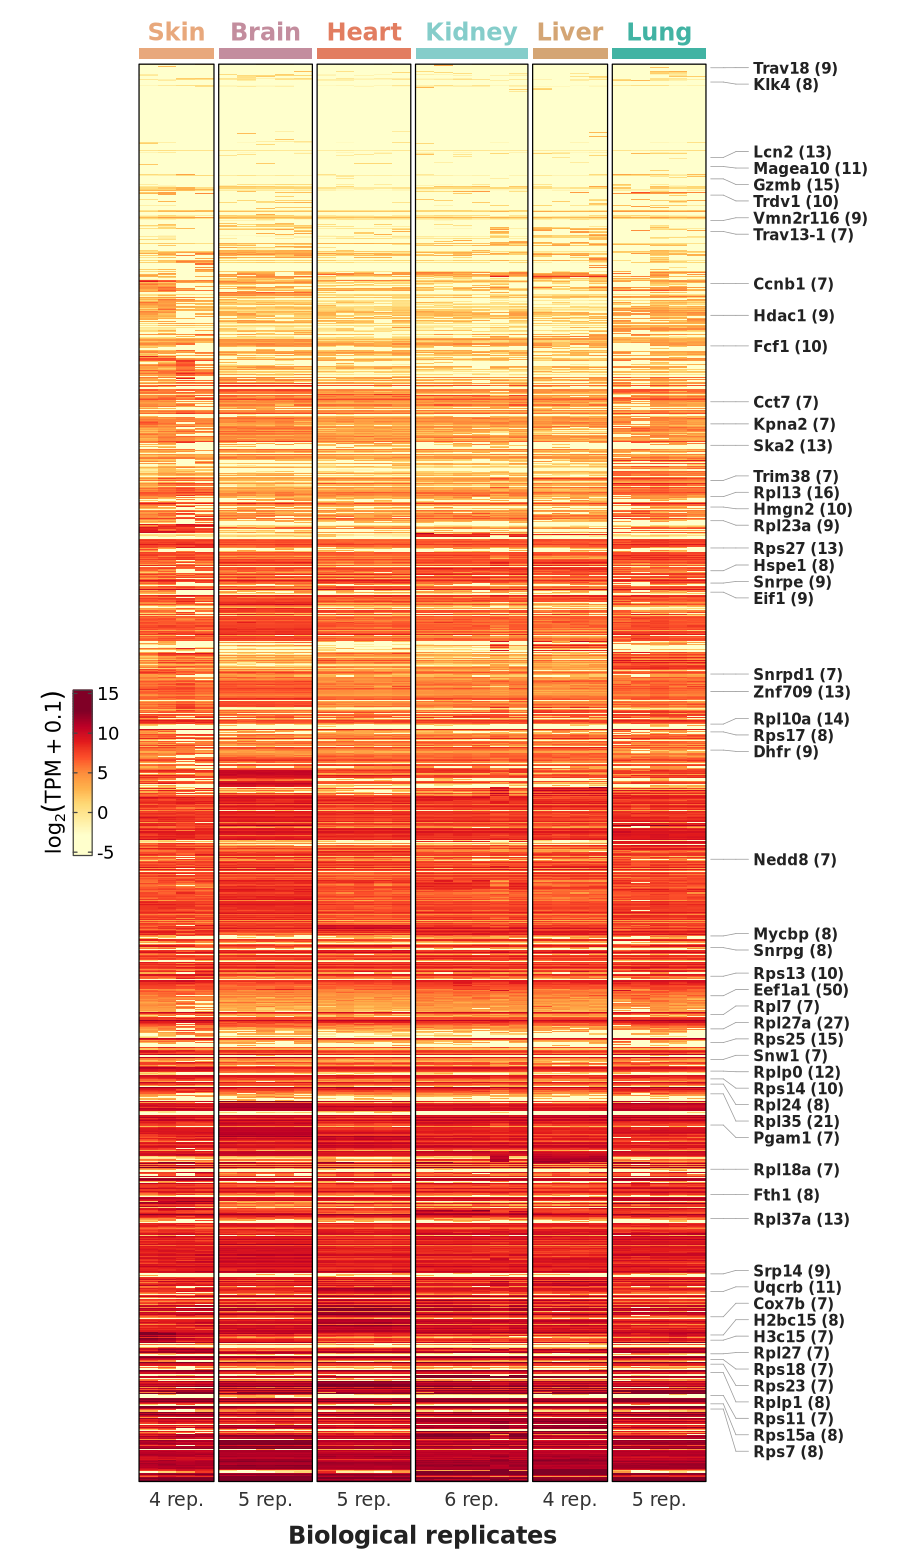

In [16]:
# ============================================================================
# JUPYTER PREVIEW
#
# Run this section to display the heatmap directly below the notebook cell.
# Do not call dev.off() after an inline preview.
# ============================================================================

options(
  repr.plot.width = PREVIEW_WIDTH_IN,
  repr.plot.height = PREVIEW_HEIGHT_IN,
  repr.plot.res = 120
)

ht_preview <- draw_paralog_heatmap(ht)



In [17]:
# ============================================================================
# SAVING FUNCTIONS
#
# These are defined but not executed automatically.
# Call save_paralog_pdf() or save_paralog_png() in a separate cell.
# ============================================================================

save_paralog_pdf <- function(
    filename = "paralog_expression_heatmap_top40_families.pdf",
    width = OUTPUT_WIDTH_IN,
    height = OUTPUT_HEIGHT_IN
) {
  pdf(
    filename,
    width = width,
    height = height,
    useDingbats = FALSE
  )

  draw_paralog_heatmap(ht)

  dev.off()

  cat("Saved:", filename, "\n")
}

save_paralog_png <- function(
    filename = "paralog_expression_heatmap_top40_families.png",
    width = OUTPUT_WIDTH_IN,
    height = OUTPUT_HEIGHT_IN,
    resolution = 400
) {
  png(
    filename,
    width = width,
    height = height,
    units = "in",
    res = resolution
  )

  draw_paralog_heatmap(ht)

  dev.off()

  cat("Saved:", filename, "\n")
}

cat(
  "\nPreview displayed above.\n",
  "To save, run one or both of these commands:\n\n",
  'save_paralog_pdf()\n',
  'save_paralog_png()\n'
)


Preview displayed above.
 To save, run one or both of these commands:

 save_paralog_pdf()
 save_paralog_png()


In [18]:
 save_paralog_png()


Saved: paralog_expression_heatmap_top40_families.png 
